Como Método a seguir / modelo de referencia uno puede generalizarlo a los siguientes pasos:
# *Cargar ➔ Explorar ➔ Transformar ➔ Agrupar ➔ Guardar*

En donde

el 1ro *CARGAR*, acá tenemos que entender que archivo es y cuál es su naturaleza

el 2do *EXPLORAR*,  es donde siempre chequeamos si hay errores Y donde más común darse cuenta de errores del dataset

el 3ro *TRANSFORMAR*  (filtrado, agregar columnas o sacar filas)

el 4to *AGRUPAR*  (groupby)

el 5to *GUARDAR* , Fijarse si uno quiere que sea para Formato EEUU o Español


---
# Vamos a ver 2 Casos:
# Registro de Propinas de un Restaurant y Marcas Entrenamiento Gimnasio


En ambos vamos a seguir el mismo método, que fue fundamentado en la clase teórica.


Así analizamos las diferentes situaciones al tratar con datasets más o menos amigables.



---
# **1er Caso**
/ Registro de Propinas


---
1) **CARGAR**

In [2]:
import pandas as pd

# 1. Definimos la URL directa al repositorio de GitHub
URL_caso1 = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

# 2. Leemos el archivo y lo guardamos en nuestro dataframe "df"
df = pd.read_csv(URL_caso1)

# Vemos las primeras 5 filas para entender qué hay adentro
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Vemos, las columnas que tenemos y la estructura del dataframe

---
2)  **EXPLORAR**

In [3]:
# ¿Cuántas filas y columnas tiene?
print("Dimensión:", df.shape)

#Vemos que columnas tiene, corroboramos si es lo que creiamos...
print("\nCOLUMNAS :", list(df.columns))

# ¿De qué tipo es cada columna y hay datos faltantes (nulos)?
df.info()

# Resumen estadístico rápido (promedio de cuentas, propina máxima, etc.)
df.describe()

Dimensión: (244, 7)

COLUMNAS : ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Por ahora vemos que este dataframe es bastante amigable, al no tener espacios vacios y no ser tan profundo en contenido...

Lo que si podriamos intuir que los datos que son object hay que tener cuidado...

---
3) **TRANSFORMAR**

In [4]:
# Creamos una columna nueva, con el porcentaje de propina de cada registro
df["porcentaje_propina"] = ((df["tip"] / df["total_bill"]) * 100).round(2)

# Filtramos las cenas de los finde semanas
# Usamos los paréntesis para separar condiciones.
cenas_finde = df[(df["time"] == "Dinner") & ((df["day"] == "Sat") | (df["day"] == "Sun"))]

print("Cantidad de mesas de fin de semana a la noche:", len(cenas_finde))
cenas_finde.head()

Cantidad de mesas de fin de semana a la noche: 163


,total_bill,tip,sex,smoker,day,time,size,porcentaje_propina
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68


In [5]:
# Filtramos propinas mayores o iguales a 20
propinas_altas = df[df["porcentaje_propina"] >= 20]

print("Cantidad de mesas con excelentes propinas:", len(propinas_altas))

propinas_altas.head()

Cantidad de mesas con excelentes propinas: 39


,total_bill,tip,sex,smoker,day,time,size,porcentaje_propina
6,8.77,2.00,Male,No,Sun,Dinner,2,22.81
9,14.78,3.23,Male,No,Sun,Dinner,2,21.85
14,14.83,3.02,Female,No,Sun,Dinner,2,20.36
17,16.29,3.71,Male,No,Sun,Dinner,3,22.77
18,16.97,3.50,Female,No,Sun,Dinner,3,20.62


---
4)  **AGRUPAR**

In [6]:
# groupby("day") arma los grupos por día
# ["total_bill"].sum() suma la facturación de cada grupo
# sort_values(ascending=False) lo ordena de mayor a menor

facturacion_por_dia = (df.groupby("day")["total_bill"].sum().sort_values(ascending=False)).round()
Propina_por_dia = (df.groupby("day")["tip"].sum().sort_values(ascending=False)).round()

print(facturacion_por_dia)
print(f"\n{Propina_por_dia}")

day
Sat     1778.0
Sun     1627.0
Thur    1096.0
Fri      326.0
Name: total_bill, dtype: float64

day
Sat     260.0
Sun     247.0
Thur    172.0
Fri      52.0
Name: tip, dtype: float64


o MÁS INTERESANTE el porcentaje promedio de propia por dia

In [7]:
Porcentaje_promedio_propina_por_dia = (df.groupby("day")["porcentaje_propina"].mean().sort_values(ascending=False)).round(2)
print(Porcentaje_promedio_propina_por_dia)

day
Fri     16.99
Sun     16.69
Thur    16.13
Sat     15.31
Name: porcentaje_propina, dtype: float64


---
5) **GUARDAR**

In [8]:
# Formato Español
# Lo guardamos con separador ";" y decimal ","
# index=True porque en este caso el índice "day" contiene los nombres de los días y queremos conservarlo.
facturacion_por_dia.to_csv("facturacion_Bar.csv", sep=";", decimal=",", index=True)

print("¡Archivo exportado con éxito, Formato EXCEL Español! ✅")



¡Archivo exportado con éxito, Formato EXCEL Español! ✅


**`Extra`**

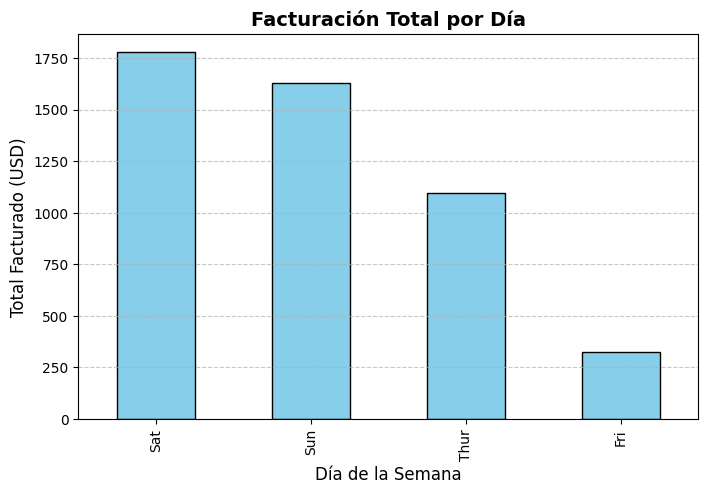

In [22]:
# Importamos la librería estrella de visualización (suele importarse al principio, pero la ponemos acá para probar)
import matplotlib.pyplot as plt

# 1. Preparamos el "lienzo" (ancho, alto)
plt.figure(figsize=(8, 5))

# 2. Dibujamos el gráfico de barras (Eje X: Los días, Eje Y: La plata)

facturacion_por_dia.plot(kind="bar", color="skyblue", edgecolor="black")

# 3. Le ponemos títulos para que hable por sí solo (¡Cero ruido!)
plt.title("Facturación Total por Día", fontsize=14, fontweight='bold')
plt.xlabel("Día de la Semana", fontsize=12)
plt.ylabel("Total Facturado (USD)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Una grilla sutil de fondo

# 4. Lo mostramos en pantalla
plt.show()


La visualización de información por librerías como matplotlib y seaborn se van a ver a detalle en la Notebook 02: "Visualización de datos"

---
# 2do Caso
/ Base de Marcas de entrenamiento, Útil para trackeo de Marcas y análisis de progreso, anotas desde el celular en el gimnasio cada ejercicio.


---
1)  **CARGAR**

In [10]:
#como ya importamos Pandas, no es necesario importarlo de nuevo...
URL_Caso2 = "https://raw.githubusercontent.com/fglsr0912b/Base-Datos-Genericas/refs/heads/main/mis_entrenamientos_masivo.csv"
# Leemos el archivo CSV.
df_gym = pd.read_csv(URL_Caso2)

# Miramos las primeras filas para confirmar que cargó bien
df_gym.head()

,fecha,grupo_muscular,ejercicio,series,repeticiones,peso_kg
0,2023-01-01,Piernas,Peso Muerto Rumano,3,12,93.2
1,2023-01-01,Piernas,Sentadilla Libre,4,10,80.2
2,2023-01-01,Piernas,Sentadilla Libre,3,5,80.7
3,2023-01-01,Pecho,Press Banco Plano,5,12,85.7
4,2023-01-01,Pecho,Aperturas Mancuernas,4,8,77.6


---
2) **EXPLORAR**

In [11]:
#hacemos el inventario principal visto en la teorica
print("🔍 INVENTARIO DEL DATASET MASIVO")
print("\nDimensión total:", df_gym.shape)
print("\nTipos y Faltantes:")
df_gym.info()

🔍 INVENTARIO DEL DATASET MASIVO

Dimensión total: (5475, 6)

Tipos y Faltantes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5475 entries, 0 to 5474
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fecha           5475 non-null   object 
 1   grupo_muscular  5475 non-null   object 
 2   ejercicio       5475 non-null   object 
 3   series          5475 non-null   int64  
 4   repeticiones    5475 non-null   int64  
 5   peso_kg         5185 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 256.8+ KB


Vemos, que la mayoría de columnas están completas, menos la de Peso, así que tenemos cuidado al tratar con ella


Corroboramos que en las variables donde hay números, sean datos del tipo int o float, para así poder operar aritméticamente con ellos


**Disclaimer**: *el peso en realidad es un fuerza, por ende su unidad debería estar en newton, pero también se usa coloquialmente como si fuera la masa*


---
3) **TRANSFORMAR**



Como habíamos visto el data frame tenia variables vacias, asi que "limpiamos" el data frame y sacamos las filas sin datos


In [12]:
#Usamos el metodo dropna solo en la columna "peso_kg" para que las elimine si tiene una variable null
df_gym_limpio = df_gym.dropna(subset=["peso_kg"]).copy()

print("🧹 Dimensión post-limpieza:", df_gym_limpio.shape)

🧹 Dimensión post-limpieza: (5185, 6)


In [13]:
# CREAR COLUMNA NUEVA: Volumen total movido en esa sesión
df_gym_limpio["volumen_total_kg"] = df_gym_limpio["series"] * df_gym_limpio["repeticiones"] * df_gym_limpio["peso_kg"]

# FILTRAR: Nos quedamos solo con los días que hiciste Sentadilla
historial_sentadilla = df_gym_limpio[df_gym_limpio["ejercicio"] == "Sentadilla Libre"].copy()

historial_sentadilla.head()

,fecha,grupo_muscular,ejercicio,series,repeticiones,peso_kg,volumen_total_kg
1,2023-01-01,Piernas,Sentadilla Libre,4,10,80.2,3208.0
2,2023-01-01,Piernas,Sentadilla Libre,3,5,80.7,1210.5
15,2023-01-02,Piernas,Sentadilla Libre,4,7,98.0,2744.0
26,2023-01-02,Piernas,Sentadilla Libre,4,7,90.5,2534.0
52,2023-01-04,Piernas,Sentadilla Libre,4,8,85.1,2723.2


---
4)  **AGRUPAR**


In [14]:
# Récord de peso máximo por ejercicio
records_peso = df_gym_limpio.groupby("ejercicio")["peso_kg"].max().sort_values(ascending=False)

print("\n🏆 Récords de Peso (kg):")
print(records_peso)

# Volumen total movido agrupado por grupo muscular
volumen_por_musculo = df_gym_limpio.groupby("grupo_muscular")["volumen_total_kg"].sum().sort_values(ascending=False)

print("\n💪 Volumen Total por Músculo (kg):")
print(volumen_por_musculo.round())


🏆 Récords de Peso (kg):
ejercicio
Press Inclinado         100.0
Aperturas Mancuernas     99.9
Remo con Barra           99.9
Prensa                   99.9
Sentadilla Libre         99.9
Dominadas                99.8
Press Banco Plano        99.8
Peso Muerto Rumano       99.8
Curl con Barra           54.9
Extensiones en Polea     54.9
Name: peso_kg, dtype: float64

💪 Volumen Total por Músculo (kg):
grupo_muscular
Pecho      5003102.0
Piernas    4921885.0
Espalda    3115083.0
Tríceps     654642.0
Bíceps      606286.0
Name: volumen_total_kg, dtype: float64


---
5) **GUARDAR**

In [15]:
# Guardamos los récords en un archivo limpio para visualizar en Excel
records_peso.to_csv("Records_Marcas.csv", sep=";", decimal=",")

print("¡Archivo guardado con éxito, Formato EXCEL Español! ✅")

¡Archivo guardado con éxito, Formato EXCEL Español! ✅


**`Extra`**

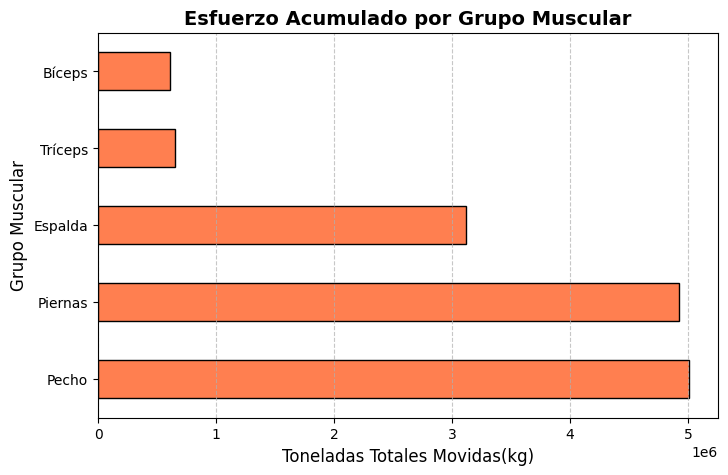

In [25]:
#No importo nuevamente la libreria matplotlib, porque ya la importamos anteriormente

plt.figure(figsize=(8, 5))

# Acá usamos barh (barras horizontales), ideal para que los nombres de los músculos se lean bien.
volumen_por_musculo.plot(
    kind="barh",
    color="coral",
    edgecolor="black")

#Definimos que son cada Eje y el titulo general del grafico
plt.title("Esfuerzo Acumulado por Grupo Muscular", fontsize=14, fontweight='bold')
plt.xlabel("Toneladas Totales Movidas(kg)", fontsize=12)
plt.ylabel("Grupo Muscular", fontsize=12)

#
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

---
A modo de RESUMEN de estos casos vistos:


Seguir el Metodo, y en base a el dataframe con el que se trabaje, produndizar para x lado.

# *Cargar ➔ Explorar ➔ Transformar ➔ Agrupar ➔ Guardar*



| Etapa y Error a evitar | Comando / Solución |
|---|---|
| **Cargar:** Formato regional roto por separadores | Usar `sep=";"` y `decimal=","` (o borrarlos) |
| **Explorar:** Operar matemáticamente sobre nulos | `df.dropna(subset=["columna_clave"])` |
| **Transformar:** Arrastrar columnas inútiles | `df_util = df[["col1", "col2"]].copy()` |
| **Agrupar:** Agrupar la tabla entera sin definir objetivo | `df.groupby("grupo")["col_objetivo"].sum()` |